# Knee Angle Prediction with Tube Loss
### Georgia Tech Pre-Training → UCI Transfer Learning (SIC & DIC)

**Pipeline:**
1. Tube Loss replaces MSE throughout — network outputs **two neurons** (lower bound µ₁, upper bound µ₂)
2. Pre-train SIC model on Georgia Tech dataset using Tube Loss
3. Transfer Stage-1 (population adapt) + Stage-2 (subject fine-tune) for UCI Normal & Abnormal
4. DIC model inherits EMG CNN weights from SIC pre-training, then trains kinematic branch with Tube Loss
5. Evaluate with both **interval metrics** (PICP, MPIW) and **point metrics** (MAE via midpoint)

**Tube Loss reference:** Anand et al. 2024 — https://github.com/ltpritamanand/Tube_loss

---
**Lightning AI note:** All cells run as-is. Set `DATA_DIR` paths in Cell 2 before running.

In [1]:
# ── Cell 1: Install dependencies ─────────────────────────────────────────────
# Uncomment if packages are missing on Lightning AI
# !pip install scipy scikit-learn torch tqdm matplotlib

In [2]:
# ── Cell 2: GLOBAL CONFIGURATION ─────────────────────────────────────────────
import os

class Config:
    # ── Paths ────────────────────────────────────────────────────────────────
    GT_DATA_DIR      = "./python_ready"          # Georgia Tech .mat files
    UCI_NORMAL_DIR   = "./UCI/N_TXT"             # UCI normal walking .txt files
    UCI_ABNORMAL_DIR = "./UCI/A_TXT"             # UCI abnormal walking .txt files
    CHECKPOINT_DIR   = "./checkpoints_tube"      # saved model weights

    # ── Signal processing ────────────────────────────────────────────────────
    EMG_FS    = 1000   # Hz (Georgia Tech & UCI)
    GON_FS    = 1000   # Hz
    TARGET_FS = 100    # Hz after downsampling
    HP_CUTOFF = 20.0   # High-pass cutoff (Hz)
    LP_CUTOFF = 4.0    # Low-pass envelope cutoff (Hz)

    # ── Windowing ────────────────────────────────────────────────────────────
    WINDOW_SIZE   = 200   # 2 s @ 100 Hz
    STEP_SIZE     = 4     # 40 ms overlap
    PREDICT_STEPS = 1     # 1-step ahead (10 ms)

    # ── Tube Loss hyperparameters ─────────────────────────────────────────────
    # t  : target confidence level  (e.g. 0.90 → 90% PI)
    # r  : tube centering parameter (0.5 = symmetric / centered PI)
    #      decrease r to shift tube down (useful for skewed distributions)
    # delta : explicit width regulariser (0 = off; increase to narrow after over-coverage)
    TUBE_T     = 0.90
    TUBE_R     = 0.50
    TUBE_DELTA = 0.00

    # ── Pre-training (Georgia Tech SIC) ──────────────────────────────────────
    GT_TEST_SUBJECT_IDX = 21    # 0-based; last subject held out
    GT_TRAIN_RATIO      = 0.80
    GT_BATCH_SIZE       = 2000
    GT_MAX_EPOCHS       = 80
    GT_PATIENCE         = 12
    GT_LR               = 5e-4

    # ── Stage-1 transfer (population adaptation) ─────────────────────────────
    S1_EPOCHS        = 80
    S1_PATIENCE      = 12
    S1_BATCH         = 64
    S1_WD            = 1e-4
    S1_LR_CNN        = 1e-4
    S1_LR_HEAD_MANY  = 1e-3    # >3000 training windows (abnormal)
    S1_LR_HEAD_FEW   = 5e-4    # <3000 training windows (normal)
    S1_THRESHOLD     = 3000

    # ── Stage-2 transfer (subject fine-tune) ─────────────────────────────────
    S2_LR_INIT       = 2e-4
    S2_LR_MIN        = 1e-5
    S2_WD            = 1e-3
    S2_STEPS_TARGET  = 600     # target gradient steps (SIC adaptive)
    S2_FIXED_EPOCHS  = 25      # DIC uses fixed epochs (paper protocol)

    # ── Evaluation ───────────────────────────────────────────────────────────
    WALK_KEYWORDS    = ["mar"]  # UCI: only walking files
    TEST_FT_FRAC     = 0.50    # 50 / 50 fine-tune / eval split
    MIN_RANGE_DEG    = 30.0    # fall back to train_range if test range too small
    PRIMARY_LOO_IDX  = 10      # paper's benchmark subject (subject 11, 0-based)
    RUN_ALL_LOO      = True    # run all 11 LOO folds

    DEVICE = "cuda" if __import__('torch').cuda.is_available() else "cpu"

cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
print(f"Device: {cfg.DEVICE}")
print(f"Tube Loss: t={cfg.TUBE_T}, r={cfg.TUBE_R}, delta={cfg.TUBE_DELTA}")

Device: cuda
Tube Loss: t=0.9, r=0.5, delta=0.0


## Section 1 — Tube Loss Implementation
Direct PyTorch implementation of Equation (18) from Anand et al. 2024.

$$\rho_t^r(y, \mu_1, \mu_2) = \begin{cases} t(y-\mu_2) & y > \mu_2 \\ (1-t)(\mu_2-y) & \mu_1 \le y \le \mu_2,\ y \ge r\mu_2+(1-r)\mu_1 \\ (1-t)(y-\mu_1) & \mu_1 \le y \le \mu_2,\ y < r\mu_2+(1-r)\mu_1 \\ t(\mu_1-y) & y < \mu_1 \end{cases}$$

In [3]:
# ── Cell 3: Tube Loss ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn

class TubeLoss(nn.Module):
    """
    Tube Loss for simultaneous PI estimation (Anand et al. 2024).

    Network output: two nodes per predict_step — [mu1, mu2]  (lower, upper)
    Convention enforced: mu1 = lower, mu2 = upper  (sorted inside forward).

    Parameters
    ----------
    t     : confidence level  (e.g. 0.90 → 90% PI)
    r     : tube position     (0.5 = centred; <0.5 shifts tube down)
    delta : width penalty     (0 = disabled; >0 shrinks width after over-coverage)
    """
    def __init__(self, t: float = 0.90, r: float = 0.50, delta: float = 0.0):
        super().__init__()
        assert 0 < t < 1, "t must be in (0,1)"
        assert 0 < r < 1, "r must be in (0,1)"
        self.t     = t
        self.r     = r
        self.delta = delta

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred   : (B, 2)  — columns [mu1_raw, mu2_raw]
        target : (B, 1)  — z-scored knee angle
        """
        t, r = self.t, self.r

        # Ensure mu1 ≤ mu2 by sorting (soft constraint)
        mu1 = torch.min(pred[:, 0], pred[:, 1]).unsqueeze(1)  # (B,1) lower
        mu2 = torch.max(pred[:, 0], pred[:, 1]).unsqueeze(1)  # (B,1) upper
        y   = target  # (B,1)

        # Dividing line inside interval: r*mu2 + (1-r)*mu1
        mid = r * mu2 + (1.0 - r) * mu1                       # (B,1)

        # Four regions  (Eq. 18)
        above    = (y > mu2).float()
        inside_u = ((y >= mu1) & (y <= mu2) & (y >= mid)).float()
        inside_l = ((y >= mu1) & (y <= mu2) & (y <  mid)).float()
        below    = (y < mu1).float()

        loss = (
            above    *       t  * (y - mu2)
          + inside_u * (1 - t) * (mu2 - y)
          + inside_l * (1 - t) * (y - mu1)
          + below    *       t  * (mu1 - y)
        )                                                      # (B,1)

        tube_loss = loss.mean()

        # Optional width penalty  (Eq. 21)
        if self.delta > 0:
            width_penalty = self.delta * (mu2 - mu1).abs().mean()
            tube_loss = tube_loss + width_penalty

        return tube_loss

    def extra_repr(self):
        return f"t={self.t}, r={self.r}, delta={self.delta}"
# ── Cell 3b: Combined Loss (Tube + MSE on midpoint) ──────────────────────────
import torch.nn.functional as F

class CombinedLoss(nn.Module):
    """
    Tube Loss for interval coverage + MSE on the midpoint for point accuracy.
    """
    def __init__(self, t: float = 0.90, r: float = 0.50, delta: float = 0.0,
                 mse_weight: float = 0.3):
        super().__init__()
        self.tube_loss = TubeLoss(t, r, delta)
        self.mse_weight = mse_weight

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # pred: (B, 2)  columns: [mu1_raw, mu2_raw]
        mu1 = torch.min(pred[:, 0:1], pred[:, 1:2])
        mu2 = torch.max(pred[:, 0:1], pred[:, 1:2])
        midpoint = (mu1 + mu2) / 2.0

        tube = self.tube_loss(pred, target)          # use the TubeLoss forward
        mse  = F.mse_loss(midpoint, target)

        return (1.0 - self.mse_weight) * tube + self.mse_weight * mse

    def extra_repr(self):
        return (f"t={self.tube_loss.t}, r={self.tube_loss.r}, "
                f"delta={self.tube_loss.delta}, mse_weight={self.mse_weight}")

# ── Quick sanity check ────────────────────────────────────────────────────────
import torch
_loss_fn = TubeLoss(t=0.9, r=0.5)
_pred    = torch.tensor([[-0.5, 0.5], [-1.0, 1.0], [0.1, 0.9]])  # lower, upper
_target  = torch.tensor([[0.2], [-0.5], [1.2]])
_val     = _loss_fn(_pred, _target)
print(f"TubeLoss sanity: {_val.item():.4f}  (expect small positive number)")

# All values inside → near zero loss
_pred2   = torch.tensor([[-2.0, 2.0]])
_target2 = torch.tensor([[0.0]])
print(f"Wide interval covering target: {_loss_fn(_pred2, _target2).item():.4f}  (expect ≈0)")

# Point outside → positive loss
_pred3   = torch.tensor([[0.0, 1.0]])
_target3 = torch.tensor([[-1.0]])
print(f"Target below lower bound: {_loss_fn(_pred3, _target3).item():.4f}  (expect >0)")

# ── Reproducibility ──────────────────────────────────────────────────────────
import torch
import numpy as np
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
print('Seeds set for reproducibility.')


TubeLoss sanity: 0.1167  (expect small positive number)
Wide interval covering target: 0.2000  (expect ≈0)
Target below lower bound: 0.9000  (expect >0)
Seeds set for reproducibility.


## Section 2 — Model Architectures
Both SIC and DIC output **2 values per predict step**: `[µ₁ (lower), µ₂ (upper)]`

In [4]:
# ── Cell 4: SIC Model (output: 2 per predict_step) ────────────────────────────

class ChannelCNN(nn.Module):
    """1-D CNN per EMG channel.  (B,1,200) → (B,32,50)"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,  16, kernel_size=7, padding=3), nn.ReLU(inplace=True),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(inplace=True),
            nn.AvgPool1d(kernel_size=4),
        )
    def forward(self, x): return self.net(x)


class CNNLSTM_SIC_Tube(nn.Module):
    """
    SIC model with Tube Loss head.
    Output: (B, 2) = [mu1, mu2]  (lower & upper bound in z-score space)
    """
    def __init__(self, predict_steps: int = 1, dropout: float = 0.0):
        super().__init__()
        self.predict_steps = predict_steps
        self.ch_cnns = nn.ModuleList([ChannelCNN() for _ in range(4)])
        self.lstm1   = nn.LSTM(128, 64, batch_first=True)
        self.drop    = nn.Dropout(dropout)
        self.lstm2   = nn.LSTM(64,  32, batch_first=True)
        # KEY CHANGE: 2 outputs per step (lower, upper)
        self.head    = nn.Linear(32, 2 * predict_steps)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if   "weight_ih" in name: nn.init.xavier_uniform_(p)
            elif "weight_hh" in name: nn.init.orthogonal_(p)
            elif "bias"      in name: nn.init.zeros_(p)
            elif "conv"      in name and "weight" in name:
                nn.init.kaiming_normal_(p, nonlinearity="relu")

    def forward(self, x):
        """x: (B,4,200) → (B, 2) for predict_steps=1"""
        feats = [cnn(x[:, i:i+1, :]) for i, cnn in enumerate(self.ch_cnns)]
        z = torch.cat(feats, dim=1).permute(0, 2, 1)  # (B,50,128)
        z, _ = self.lstm1(z)                           # (B,50,64)
        z = self.drop(z)
        z, _ = self.lstm2(z)                           # (B,50,32)
        out = self.head(z[:, -1, :])                   # (B, 2)
        return out

    def get_bounds(self, x):
        """Returns (mu1, mu2) sorted so mu1 ≤ mu2."""
        out = self.forward(x)
        mu1 = torch.min(out[:, 0:1], out[:, 1:2])
        mu2 = torch.max(out[:, 0:1], out[:, 1:2])
        return mu1, mu2

    def get_midpoint(self, x):
        """Returns midpoint (mu1+mu2)/2 for point-estimate metrics."""
        mu1, mu2 = self.get_bounds(x)
        return (mu1 + mu2) / 2.0


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

_m = CNNLSTM_SIC_Tube()
print(f"SIC-Tube params: {count_params(_m):,}")
_x = torch.randn(8, 4, 200)
_o = _m(_x)
print(f"Output shape: {_o.shape}  (expected (8, 2))")

SIC-Tube params: 73,154
Output shape: torch.Size([8, 2])  (expected (8, 2))


In [5]:
# ── Cell 5: DIC Attention Model with Tube Loss head ───────────────────────────

class AttentionFusion(nn.Module):
    """Kinematic LSTM hidden states attend over 4 EMG channel features."""
    def __init__(self, emg_feat_dim=32, kin_hidden=64):
        super().__init__()
        self.emg_proj = nn.Linear(emg_feat_dim, kin_hidden)
        self.attn_fc  = nn.Linear(kin_hidden * 2, 1)

    def forward(self, kin_hidden, emg_feats):
        """kin_hidden: (B,50,64), emg_feats: list of 4×(B,32,50) → (B,50,96)"""
        attn_weights, emg_proj_list = [], []
        for feat in emg_feats:
            f      = feat.permute(0, 2, 1)            # (B,50,32)
            f_proj = self.emg_proj(f)                  # (B,50,64)
            emg_proj_list.append(f_proj)
            score  = self.attn_fc(torch.cat([kin_hidden, f_proj], dim=-1)).squeeze(-1)
            attn_weights.append(torch.softmax(score, dim=-1))
        emg_stacked  = torch.stack([f.permute(0,2,1) for f in emg_feats], dim=1)  # (B,4,50,32)
        attn_stacked = torch.stack(attn_weights, dim=1)                            # (B,4,50)
        emg_weighted = (emg_stacked * attn_stacked.unsqueeze(-1)).sum(dim=1)       # (B,50,32)
        return torch.cat([kin_hidden, emg_weighted], dim=-1)                       # (B,50,96)


class CNNLSTM_DIC_Tube(nn.Module):
    """
    DIC attention model with Tube Loss head.
    Inputs : emg (B,4,200), knee_hist (B,200)
    Output : (B, 2) = [mu1, mu2]
    """
    def __init__(self, predict_steps=1, dropout=0.3):
        super().__init__()
        self.emg_cnns     = nn.ModuleList([ChannelCNN() for _ in range(4)])
        self.kin_lstm     = nn.LSTM(input_size=4, hidden_size=64, batch_first=True)
        self.attn_fusion  = AttentionFusion(emg_feat_dim=32, kin_hidden=64)
        self.lstm1        = nn.LSTM(64+32, 64, batch_first=True)
        self.drop         = nn.Dropout(dropout)
        self.lstm2        = nn.LSTM(64, 32, batch_first=True)
        self.head         = nn.Linear(32, 2 * predict_steps)  # 2 outputs

    def forward(self, emg, knee_hist):
        emg_feats = [self.emg_cnns[i](emg[:, i:i+1, :]) for i in range(4)]
        knee_in   = knee_hist.view(-1, 50, 4)         # (B,50,4)
        kin_out, _ = self.kin_lstm(knee_in)            # (B,50,64)
        fused      = self.attn_fusion(kin_out, emg_feats)  # (B,50,96)
        out, _     = self.lstm1(fused)                 # (B,50,64)
        out        = self.drop(out)
        out, _     = self.lstm2(out)                   # (B,50,32)
        return self.head(out[:, -1, :])                # (B, 2)

    def get_bounds(self, emg, knee_hist):
        out = self.forward(emg, knee_hist)
        mu1 = torch.min(out[:, 0:1], out[:, 1:2])
        mu2 = torch.max(out[:, 0:1], out[:, 1:2])
        return mu1, mu2

    def get_midpoint(self, emg, knee_hist):
        mu1, mu2 = self.get_bounds(emg, knee_hist)
        return (mu1 + mu2) / 2.0


_dic = CNNLSTM_DIC_Tube()
print(f"DIC-Tube params: {count_params(_dic):,}")
_emg  = torch.randn(4, 4, 200)
_knee = torch.randn(4, 200)
_o2   = _dic(_emg, _knee)
print(f"DIC output shape: {_o2.shape}  (expected (4, 2))")

DIC-Tube params: 85,123
DIC output shape: torch.Size([4, 2])  (expected (4, 2))


## Section 3 — Preprocessing & Windowing (shared)

In [6]:
# ── Cell 6: Signal preprocessing utilities ────────────────────────────────────
import numpy as np
import scipy.signal as sp_signal
import scipy.io as sio
import glob
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)


# ── KneeScaler (z-score) ──────────────────────────────────────────────────────
class KneeScaler:
    def __init__(self):
        self.mean = 0.0; self.std = 1.0
    def fit(self, y):
        self.mean = float(np.mean(y)); self.std = float(max(np.std(y), 1e-6))
        return self
    def transform(self, y):
        return ((np.asarray(y, np.float64) - self.mean) / self.std).astype(np.float32)
    def inverse(self, y):
        return (np.asarray(y, np.float64) * self.std + self.mean).astype(np.float32)
    def state(self): return {"mean": self.mean, "std": self.std}
    def __repr__(self): return f"KneeScaler(mean={self.mean:.2f}°, std={self.std:.2f}°)"


# ── EMG preprocessing ─────────────────────────────────────────────────────────
def preprocess_emg(emg: np.ndarray, orig_fs: int = 1000) -> np.ndarray:
    """HP(20Hz) → |rectify| → LP(4Hz) → downsample to TARGET_FS."""
    nyq = orig_fs / 2.0
    hp  = sp_signal.butter(2, cfg.HP_CUTOFF / nyq, btype="high", output="sos")
    lp  = sp_signal.butter(2, cfg.LP_CUTOFF  / nyq, btype="low",  output="sos")
    proc = np.empty_like(emg, dtype=np.float64)
    for ch in range(emg.shape[1]):
        s = sp_signal.sosfiltfilt(hp, emg[:, ch])
        s = np.abs(s)
        s = sp_signal.sosfiltfilt(lp, s)
        proc[:, ch] = s
    factor = orig_fs // cfg.TARGET_FS
    return proc[::factor, :].astype(np.float32)


# ── SIC windows ───────────────────────────────────────────────────────────────
def create_windows_sic(emg_ds, knee_ds, scaler) -> Tuple[np.ndarray, np.ndarray]:
    """Returns X:(W,4,200), y:(W,1) z-scored"""
    ws, ss, ps = cfg.WINDOW_SIZE, cfg.STEP_SIZE, cfg.PREDICT_STEPS
    X_list, y_list = [], []
    for start in range(0, len(knee_ds) - ws - ps + 1, ss):
        end = start + ws
        w   = emg_ds[start:end].copy()
        w   = (w - w.mean(0, keepdims=True)) / (w.std(0, keepdims=True) + 1e-8)
        t_raw = knee_ds[end:end+ps]
        if len(t_raw) < ps: break
        X_list.append(w.T)                    # (4, 200)
        y_list.append(scaler.transform(t_raw))  # (1,)
    if not X_list:
        return np.empty((0,4,ws), np.float32), np.empty((0,ps), np.float32)
    return np.array(X_list, np.float32), np.array(y_list, np.float32)


# ── DIC windows ───────────────────────────────────────────────────────────────
def create_windows_dic(emg_ds, knee_ds, scaler):
    """Returns X_emg:(W,4,200), X_knee:(W,200), y:(W,1) z-scored"""
    ws, ss, ps = cfg.WINDOW_SIZE, cfg.STEP_SIZE, cfg.PREDICT_STEPS
    Xe, Xk, yl = [], [], []
    for start in range(0, len(knee_ds) - ws - ps + 1, ss):
        end = start + ws
        w   = emg_ds[start:end].copy()
        w   = (w - w.mean(0, keepdims=True)) / (w.std(0, keepdims=True) + 1e-8)
        t_raw = knee_ds[end:end+ps]
        if len(t_raw) < ps: break
        Xe.append(w.T)
        Xk.append(knee_ds[start:end].copy())
        yl.append(scaler.transform(t_raw))
    if not Xe:
        return (np.empty((0,4,ws), np.float32),
                np.empty((0,ws),   np.float32),
                np.empty((0,ps),   np.float32))
    return np.array(Xe, np.float32), np.array(Xk, np.float32), np.array(yl, np.float32)

print("Preprocessing utilities loaded.")

Preprocessing utilities loaded.


In [7]:
# ── Cell 7: Data loaders & metrics ────────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader

class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X); self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class DICDataset(Dataset):
    def __init__(self, Xe, Xk, y):
        self.Xe = torch.from_numpy(Xe)
        self.Xk = torch.from_numpy(Xk)
        self.y  = torch.from_numpy(y)
    def __len__(self): return len(self.Xe)
    def __getitem__(self, i): return self.Xe[i], self.Xk[i], self.y[i]

def make_loader_sic(X, y, batch, shuffle):
    return DataLoader(EMGDataset(X, y), batch_size=max(batch,1), shuffle=shuffle,
                      num_workers=min(2, os.cpu_count()), pin_memory=(cfg.DEVICE=="cuda"))

def make_loader_dic(Xe, Xk, y, batch, shuffle):
    return DataLoader(DICDataset(Xe, Xk, y), batch_size=max(batch,1), shuffle=shuffle,
                      num_workers=min(2, os.cpu_count()), pin_memory=(cfg.DEVICE=="cuda"))


# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_interval_metrics(y_true, mu1, mu2, full_range, train_range):
    """PICP, MPIW, normalised width (NMPIW), midpoint NMAE/R²."""
    y   = y_true.flatten(); lo = mu1.flatten(); hi = mu2.flatten()
    mid = (lo + hi) / 2.0
    rng = full_range if full_range >= cfg.MIN_RANGE_DEG else train_range
    rng = max(rng, 1e-8)

    picp  = float(np.mean((y >= lo) & (y <= hi)))
    mpiw  = float(np.mean(hi - lo))
    nmpiw = mpiw / rng
    nmae  = float(np.mean(np.abs(y - mid))) / rng
    nrmse = float(np.sqrt(np.mean((y - mid)**2))) / rng
    r2    = r2_score(y, mid)
    mae_d = float(np.mean(np.abs(y - mid)))
    return {"PICP": picp, "MPIW": mpiw, "NMPIW": nmpiw,
            "NMAE": nmae, "NRMSE": nrmse, "R2": r2, "MAE_deg": mae_d}

print("Datasets and metrics loaded.")

Datasets and metrics loaded.


## Section 4 — Training Helpers

In [8]:
# ── Cell 8 (FIXED): Training helpers — criterion always passed explicitly ─────
import torch.optim as optim

# Instantiate default criteria (used when no override is passed)
tube_criterion          = TubeLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=cfg.TUBE_DELTA)
combined_criterion_sic  = CombinedLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=0.0, mse_weight=0.30)
combined_criterion_dic  = CombinedLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=0.0, mse_weight=0.20)


def run_epoch_sic(model, loader, criterion, opt=None):
    """SIC training epoch.  criterion is passed explicitly — no globals."""
    model.train(opt is not None)
    total = 0.0
    ctx   = torch.enable_grad() if opt else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(cfg.DEVICE), y.to(cfg.DEVICE)
            pred = model(X)
            loss = criterion(pred, y)
            if opt:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item() * len(X)
    return total / max(len(loader.dataset), 1)


def run_epoch_dic(model, loader, criterion, opt=None):
    """DIC training epoch.  criterion is passed explicitly — no globals."""
    model.train(opt is not None)
    total = 0.0
    ctx   = torch.enable_grad() if opt else torch.no_grad()
    with ctx:
        for Xe, Xk, y in loader:
            Xe, Xk, y = Xe.to(cfg.DEVICE), Xk.to(cfg.DEVICE), y.to(cfg.DEVICE)
            pred = model(Xe, Xk)
            loss = criterion(pred, y)
            if opt:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item() * len(Xe)
    return total / max(len(loader.dataset), 1)


def stage1_train_sic(model, tr_ldr, vl_ldr, param_groups, wd, epochs, patience,
                     criterion, save_path):
    opt  = optim.Adam(param_groups, weight_decay=wd)
    best = float('inf'); wait = 0; best_state = None
    for ep in range(1, epochs+1):
        tl = run_epoch_sic(model, tr_ldr, criterion, opt)
        vl = run_epoch_sic(model, vl_ldr, criterion)
        if vl < best:
            best = vl; best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            wait = 0; torch.save(best_state, save_path); m='✓'
        else:
            wait += 1; m=''
        if ep <= 5 or ep % 10 == 0 or wait >= patience:
            print(f'    [S1-SIC] Ep {ep:3d}  tr={tl:.4f}  vl={vl:.4f} {m}')
        if wait >= patience: print(f'    → Early stop (ep {ep})'); break
    if best_state: model.load_state_dict(best_state)
    return model


def stage1_train_dic(model, tr_ldr, vl_ldr, lr, wd, epochs, patience,
                     criterion, save_path):
    """DIC Stage-1 — criterion passed explicitly."""
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    best = float('inf'); wait = 0; best_state = None
    for ep in range(1, epochs+1):
        tl = run_epoch_dic(model, tr_ldr, criterion, opt)
        vl = run_epoch_dic(model, vl_ldr, criterion)
        if vl < best:
            best = vl; best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            wait = 0; torch.save(best_state, save_path); m='✓'
        else:
            wait += 1; m=''
        if ep <= 5 or ep % 10 == 0 or wait >= patience:
            print(f'    [S1-DIC] Ep {ep:3d}  tr={tl:.4f}  vl={vl:.4f} {m}')
        if wait >= patience: print(f'    → Early stop (ep {ep})'); break
    if best_state: model.load_state_dict(best_state)
    return model


def stage2_cosine_sic(model, ft_X, ft_y, n_epochs, criterion, save_path):
    batch  = min(16, max(len(ft_X)//4, 1))
    loader = make_loader_sic(ft_X, ft_y, batch, shuffle=True)
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt   = optim.Adam(trainable, lr=cfg.S2_LR_INIT, weight_decay=cfg.S2_WD)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=cfg.S2_LR_MIN)
    for ep in range(1, n_epochs+1):
        run_epoch_sic(model, loader, criterion, opt); sched.step()
        if ep % max(n_epochs//5,1) == 0 or ep == n_epochs:
            print(f'    [S2-SIC] Ep {ep}/{n_epochs}  lr={opt.param_groups[0]["lr"]:.2e}')
    if save_path: torch.save({k:v.cpu().clone() for k,v in model.state_dict().items()}, save_path)
    return model


def stage2_fixed_dic(model, ft_Xe, ft_Xk, ft_y, n_epochs, criterion, save_path):
    """DIC Stage-2 — freeze EMG CNNs; criterion passed explicitly."""
    batch  = min(16, max(len(ft_Xe)//4, 4))
    loader = make_loader_dic(ft_Xe, ft_Xk, ft_y, batch, shuffle=True)
    for cnn in model.emg_cnns:
        for p in cnn.parameters(): p.requires_grad = False
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt   = optim.Adam(trainable, lr=cfg.S2_LR_INIT, weight_decay=cfg.S2_WD)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=cfg.S2_LR_MIN)
    for ep in range(1, n_epochs+1):
        run_epoch_dic(model, loader, criterion, opt); sched.step()
        if ep % max(n_epochs//5,1) == 0 or ep == n_epochs:
            print(f'    [S2-DIC] Ep {ep}/{n_epochs}  lr={opt.param_groups[0]["lr"]:.2e}')
    for p in model.parameters(): p.requires_grad = True
    if save_path: torch.save(model.state_dict(), save_path)
    return model


print('Training helpers loaded.')
print(f'  SIC criterion : {combined_criterion_sic}')
print(f'  DIC criterion : {combined_criterion_dic}')


Training helpers loaded.
  SIC criterion : CombinedLoss(
  t=0.9, r=0.5, delta=0.0, mse_weight=0.3
  (tube_loss): TubeLoss(t=0.9, r=0.5, delta=0.0)
)
  DIC criterion : CombinedLoss(
  t=0.9, r=0.5, delta=0.0, mse_weight=0.2
  (tube_loss): TubeLoss(t=0.9, r=0.5, delta=0.0)
)


## Section 5 — Pre-training on Georgia Tech (SIC + Tube Loss)

In [9]:
# ── Cell 9: Georgia Tech data loading ─────────────────────────────────────────
from tqdm.notebook import tqdm

def get_subject_map_gt(data_dir):
    files  = sorted(glob.glob(os.path.join(data_dir, "AB*_data.mat")))
    smap   = {}
    for f in files:
        subj = Path(f).stem.split("_")[0]
        smap.setdefault(subj, []).append(f)
    return smap

def load_align_gt(mat_path):
    """Load one GT .mat file → (emg_ds, knee_ds) at TARGET_FS."""
    try:
        d    = sio.loadmat(mat_path)
        emg  = d["selectedEMG"].astype(np.float64)       # (N,4)
        knee = d["kneeAngle"].flatten().astype(np.float64)
    except Exception as e:
        print(f"  ⚠ {Path(mat_path).name}: {e}"); return None
    dur   = min(len(emg)/cfg.EMG_FS, len(knee)/cfg.GON_FS)
    n_tgt = int(dur * cfg.TARGET_FS)
    if n_tgt < cfg.WINDOW_SIZE + cfg.PREDICT_STEPS + 10: return None
    emg_ds  = preprocess_emg(emg[:int(dur*cfg.EMG_FS)], cfg.EMG_FS)[:n_tgt]
    knee_ds = knee[:int(dur*cfg.GON_FS)][::cfg.GON_FS//cfg.TARGET_FS][:n_tgt].astype(np.float32)
    return emg_ds, knee_ds


print("GT loader ready. Checking data directory...")
if os.path.isdir(cfg.GT_DATA_DIR):
    gt_smap  = get_subject_map_gt(cfg.GT_DATA_DIR)
    gt_subjs = sorted(gt_smap.keys())
    print(f"  Found {len(gt_subjs)} GT subjects: {gt_subjs}")
else:
    print(f"  ⚠ Georgia Tech data not found at '{cfg.GT_DATA_DIR}'.")
    print("    Skip to Cell 12 if you already have pretrained_sic_tube.pt")
    gt_smap  = {}
    gt_subjs = []

GT loader ready. Checking data directory...
  Found 22 GT subjects: ['AB06', 'AB07', 'AB08', 'AB09', 'AB10', 'AB11', 'AB12', 'AB13', 'AB14', 'AB15', 'AB16', 'AB17', 'AB18', 'AB19', 'AB20', 'AB21', 'AB23', 'AB24', 'AB25', 'AB27', 'AB28', 'AB30']


In [10]:
# ── Cell 10: Fit KneeScaler on GT training data ────────────────────────────────
if gt_subjs:
    test_subj_gt   = gt_subjs[min(cfg.GT_TEST_SUBJECT_IDX, len(gt_subjs)-1)]
    train_subjs_gt = [s for s in gt_subjs if s != test_subj_gt]
    print(f"GT Test subject: {test_subj_gt}   Train: {len(train_subjs_gt)} subjects")

    all_knee = []
    for subj in tqdm(train_subjs_gt, desc="Scanning GT knee angles"):
        for fp in gt_smap[subj]:
            res = load_align_gt(fp)
            if res is None: continue
            _, knee = res
            split = int(len(knee) * cfg.GT_TRAIN_RATIO)
            all_knee.append(knee[:split])

    gt_scaler = KneeScaler().fit(np.concatenate(all_knee))
    print(f"\nGT KneeScaler: {gt_scaler}")
else:
    print("Skipping GT scaler (no data found).")

GT Test subject: AB30   Train: 21 subjects


Scanning GT knee angles:   0%|          | 0/21 [00:00<?, ?it/s]


GT KneeScaler: KneeScaler(mean=-23.03°, std=19.67°)


In [11]:
# ── Cell 11 (FIXED): Build windows & train GT SIC with CombinedLoss ──────────
if gt_subjs:
    tr_X, tr_y, vl_X, vl_y = [], [], [], []
    for subj in tqdm(train_subjs_gt, desc='Building GT windows'):
        for fp in gt_smap[subj]:
            res = load_align_gt(fp)
            if res is None: continue
            emg_ds, knee_ds = res
            N = len(knee_ds); sp = int(N * cfg.GT_TRAIN_RATIO)
            Xt, yt = create_windows_sic(emg_ds[:sp], knee_ds[:sp], gt_scaler)
            Xv, yv = create_windows_sic(emg_ds[sp:], knee_ds[sp:], gt_scaler)
            if len(Xt): tr_X.append(Xt); tr_y.append(yt)
            if len(Xv): vl_X.append(Xv); vl_y.append(yv)

    tr_X = np.concatenate(tr_X); tr_y = np.concatenate(tr_y)
    vl_X = np.concatenate(vl_X); vl_y = np.concatenate(vl_y)
    print(f'GT Train windows: {len(tr_X):,}   Val: {len(vl_X):,}')

    gt_model = CNNLSTM_SIC_Tube(predict_steps=cfg.PREDICT_STEPS, dropout=0.0).to(cfg.DEVICE)
    print(f'GT SIC-Tube model params: {count_params(gt_model):,}')

    tr_ldr = make_loader_sic(tr_X, tr_y, cfg.GT_BATCH_SIZE, shuffle=True)
    vl_ldr = make_loader_sic(vl_X, vl_y, cfg.GT_BATCH_SIZE, shuffle=False)

    # ── FIX: use CombinedLoss for GT pretraining (TubeLoss for GT alone
    #         was fine, but CombinedLoss ensures midpoint is well anchored)
    gt_criterion = TubeLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=0.0)  # pure Tube for GT
    gt_ckpt      = os.path.join(cfg.CHECKPOINT_DIR, 'pretrained_sic_tube.pt')

    opt_gt  = optim.Adam(gt_model.parameters(), lr=cfg.GT_LR)
    best_vl = float('inf'); wait_gt = 0; best_state_gt = None

    print('\n── Georgia Tech Pre-training (SIC + CombinedLoss) ───────────────')
    print(f'   Criterion: {gt_criterion}')
    print('   (loss starts ~0.05–0.15 at epoch 1)\n')

    for epoch in range(1, cfg.GT_MAX_EPOCHS+1):
        # ── FIX: pass gt_criterion as 3rd argument (was missing before!) ──
        tl = run_epoch_sic(gt_model, tr_ldr, gt_criterion, opt_gt)
        vl = run_epoch_sic(gt_model, vl_ldr, gt_criterion)
        m  = ''
        if vl < best_vl:
            best_vl = vl
            best_state_gt = {k:v.cpu().clone() for k,v in gt_model.state_dict().items()}
            wait_gt = 0; torch.save(best_state_gt, gt_ckpt); m = ' ✓'
        else:
            wait_gt += 1
        if epoch <= 5 or epoch % 10 == 0 or wait_gt >= cfg.GT_PATIENCE:
            print(f'  Ep {epoch:3d}/{cfg.GT_MAX_EPOCHS}  train={tl:.5f}  val={vl:.5f}{m}')
        if wait_gt >= cfg.GT_PATIENCE:
            print(f'  Early stop at epoch {epoch}'); break

    if best_state_gt: gt_model.load_state_dict(best_state_gt)
    final_gt_ckpt = os.path.join(cfg.CHECKPOINT_DIR, 'pretrained_sic_tube_final.pt')
    torch.save({'model_state_dict': gt_model.state_dict(),
                'knee_scaler': gt_scaler.state(),
                'tube_t': cfg.TUBE_T, 'tube_r': cfg.TUBE_R, 'tube_delta': cfg.TUBE_DELTA},
               final_gt_ckpt)
    print(f'\n✓ Saved: {final_gt_ckpt}')
else:
    print('Skipping GT training. Loading existing checkpoint.')


Building GT windows:   0%|          | 0/21 [00:00<?, ?it/s]

GT Train windows: 425,093   Val: 100,712
GT SIC-Tube model params: 73,154

── Georgia Tech Pre-training (SIC + CombinedLoss) ───────────────
   Criterion: TubeLoss(t=0.9, r=0.5, delta=0.0)
   (loss starts ~0.05–0.15 at epoch 1)

  Ep   1/80  train=0.15456  val=0.07224 ✓
  Ep   2/80  train=0.07409  val=0.06777 ✓
  Ep   3/80  train=0.06543  val=0.06414 ✓
  Ep   4/80  train=0.06028  val=0.06148 ✓
  Ep   5/80  train=0.05674  val=0.05900 ✓
  Ep  10/80  train=0.04625  val=0.05181 ✓
  Ep  20/80  train=0.03674  val=0.04802 ✓
  Ep  30/80  train=0.03261  val=0.04561 ✓
  Ep  40/80  train=0.03018  val=0.04771
  Ep  44/80  train=0.02950  val=0.04687
  Early stop at epoch 44

✓ Saved: ./checkpoints_tube/pretrained_sic_tube_final.pt


## Section 6 — UCI Transfer Learning
### 6a — UCI File Loading (shared for SIC & DIC)

In [12]:
# ── Cell 12: UCI file utilities ───────────────────────────────────────────────
UCI_EMG_COLS = [1, 0, 3, 2]   # BF, RF, ST, VM (matches GT channel order)
UCI_KNEE_COL = 4

def parse_uci_txt(path):
    rows = []
    try:
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                parts = line.strip().replace("\t", " ").split()
                if not parts: continue
                try: vals = [float(p) for p in parts]
                except ValueError: continue
                if len(vals) >= 5: rows.append(vals[:5])
    except: return None
    if len(rows) < cfg.WINDOW_SIZE + 10: return None
    arr = np.array(rows, np.float32)
    return arr[:, UCI_EMG_COLS], arr[:, UCI_KNEE_COL]

def load_subject_raw_uci(files):
    emg_segs, knee_segs = [], []
    for fp in files:
        res = parse_uci_txt(fp)
        if res is None: continue
        emg_raw, knee_raw = res
        emg_ds  = preprocess_emg(emg_raw, cfg.EMG_FS)
        knee_ds = knee_raw[::cfg.GON_FS//cfg.TARGET_FS]
        n = min(len(emg_ds), len(knee_ds))
        if n >= cfg.WINDOW_SIZE + cfg.PREDICT_STEPS:
            emg_segs.append(emg_ds[:n]); knee_segs.append(knee_ds[:n])
    if not emg_segs: return None
    return np.concatenate(emg_segs), np.concatenate(knee_segs)

def get_subject_groups_uci(folder):
    all_txt = sorted(glob.glob(os.path.join(folder, "*.txt")))
    walk    = [f for f in all_txt if any(kw in Path(f).stem.lower() for kw in cfg.WALK_KEYWORDS)]
    if not walk: walk = all_txt
    groups  = {}
    for f in walk:
        sid = "".join(c for c in Path(f).stem if c.isdigit())
        groups.setdefault(sid or Path(f).stem, []).append(f)
    return groups


def load_pretrained_sic_tube():
    """Load pre-trained SIC-Tube checkpoint."""
    ckpt_path = os.path.join(cfg.CHECKPOINT_DIR, "pretrained_sic_tube_final.pt")
    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}\nRun Cell 11 first.")
    ckpt  = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    state = ckpt.get("model_state_dict", ckpt)
    model = CNNLSTM_SIC_Tube(predict_steps=cfg.PREDICT_STEPS, dropout=0.0)
    model.load_state_dict(state)
    model.drop = nn.Dropout(0.3)   # add dropout for transfer
    return model.to(cfg.DEVICE)


def build_dic_from_sic_tube():
    """Build DIC model, copying ONLY EMG CNN weights from pre-trained SIC."""
    ckpt_path = os.path.join(cfg.CHECKPOINT_DIR, "pretrained_sic_tube_final.pt")
    ckpt  = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    sic_state = ckpt.get("model_state_dict", ckpt)
    dic   = CNNLSTM_DIC_Tube(predict_steps=cfg.PREDICT_STEPS, dropout=0.3)
    dic_state = dic.state_dict()
    
    # Transfer only EMG CNN weights (ch_cnns -> emg_cnns)
    for name, param in sic_state.items():
        if name.startswith("ch_cnns"):
            dic_name = name.replace("ch_cnns", "emg_cnns")
            if dic_name in dic_state:
                dic_state[dic_name] = param
    
    dic.load_state_dict(dic_state, strict=False)
    return dic.to(cfg.DEVICE)

print("UCI utilities loaded.")
for d, label in [(cfg.UCI_NORMAL_DIR, "Normal"), (cfg.UCI_ABNORMAL_DIR, "Abnormal")]:
    if os.path.isdir(d):
        g = get_subject_groups_uci(d)
        print(f"  {label}: {len(g)} subjects → {sorted(g.keys())}")
    else:
        print(f"  ⚠ {label} dir not found: {d}")

UCI utilities loaded.
  Normal: 11 subjects → ['1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9']
  Abnormal: 11 subjects → ['1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9']


In [13]:
# ── Cell 13: SIC param groups for differential LR ─────────────────────────────
def get_s1_sic_param_groups(model, head_lr):
    cnn_p, other_p = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        (cnn_p if "ch_cnns" in name else other_p).append(p)
    return [{"params": cnn_p,   "lr": cfg.S1_LR_CNN},
            {"params": other_p, "lr": head_lr}]


def build_stage1_windows_sic(train_subjs, subject_groups, scaler):
    """Per-subject 80/20 split → mixed tr/vl windows."""
    tr_X, tr_y, vl_X, vl_y = [], [], [], []
    for sid in train_subjs:
        res = load_subject_raw_uci(subject_groups[sid])
        if res is None: continue
        emg_ds, knee_ds = res
        sp  = int(len(knee_ds) * 0.80)
        Xt, yt = create_windows_sic(emg_ds[:sp], knee_ds[:sp], scaler)
        Xv, yv = create_windows_sic(emg_ds[sp:], knee_ds[sp:], scaler)
        if len(Xt): tr_X.append(Xt); tr_y.append(yt)
        if len(Xv): vl_X.append(Xv); vl_y.append(yv)
    if not tr_X: return *[np.empty((0,4,cfg.WINDOW_SIZE), np.float32)]*2, *[np.empty((0,1), np.float32)]*2
    tr_X = np.concatenate(tr_X); tr_y = np.concatenate(tr_y)
    if vl_X:
        vl_X = np.concatenate(vl_X); vl_y = np.concatenate(vl_y)
    else:
        sp2  = int(len(tr_X)*0.80)
        vl_X, vl_y = tr_X[sp2:], tr_y[sp2:]
        tr_X, tr_y = tr_X[:sp2], tr_y[:sp2]
    return tr_X, tr_y, vl_X, vl_y


def build_stage1_windows_dic(train_subjs, subject_groups, scaler):
    """Per-subject 80/20 split → mixed tr/vl DIC windows."""
    tr_Xe, tr_Xk, tr_y = [], [], []
    vl_Xe, vl_Xk, vl_y = [], [], []
    for sid in train_subjs:
        res = load_subject_raw_uci(subject_groups[sid])
        if res is None: continue
        emg_ds, knee_ds = res
        sp  = int(len(knee_ds) * 0.80)
        Xe, Xk, yt = create_windows_dic(emg_ds[:sp], knee_ds[:sp], scaler)
        Xev, Xkv, yv = create_windows_dic(emg_ds[sp:], knee_ds[sp:], scaler)
        if len(Xe):  tr_Xe.append(Xe); tr_Xk.append(Xk); tr_y.append(yt)
        if len(Xev): vl_Xe.append(Xev); vl_Xk.append(Xkv); vl_y.append(yv)
    if not tr_Xe: return [np.empty((0,4,cfg.WINDOW_SIZE), np.float32)]*2 + [np.empty((0,1), np.float32)]
    tr_Xe = np.concatenate(tr_Xe); tr_Xk = np.concatenate(tr_Xk); tr_y = np.concatenate(tr_y)
    if vl_Xe:
        vl_Xe = np.concatenate(vl_Xe); vl_Xk = np.concatenate(vl_Xk); vl_y = np.concatenate(vl_y)
    else:
        idx  = np.random.permutation(len(tr_Xe)); n_v = max(1, int(len(tr_Xe)*0.20))
        vl_Xe, vl_Xk, vl_y = tr_Xe[idx[:n_v]], tr_Xk[idx[:n_v]], tr_y[idx[:n_v]]
        tr_Xe, tr_Xk, tr_y = tr_Xe[idx[n_v:]], tr_Xk[idx[n_v:]], tr_y[idx[n_v:]]
    return tr_Xe, tr_Xk, tr_y, vl_Xe, vl_Xk, vl_y

print("Stage-1 window builders ready.")

Stage-1 window builders ready.


### 6b — LOO Evaluation Functions

In [14]:
# ── Cell 14: Predict & evaluate helpers ──────────────────────────────────────
def predict_bounds_sic(model, loader, scaler):
    model.eval(); mu1s, mu2s, trues = [], [], []
    with torch.no_grad():
        for X, y in loader:
            m1, m2 = model.get_bounds(X.to(cfg.DEVICE))
            mu1s.append(scaler.inverse(m1.cpu().numpy()))
            mu2s.append(scaler.inverse(m2.cpu().numpy()))
            trues.append(scaler.inverse(y.numpy()))
    return np.concatenate(mu1s), np.concatenate(mu2s), np.concatenate(trues)

def predict_bounds_dic(model, loader, scaler):
    model.eval(); mu1s, mu2s, trues = [], [], []
    with torch.no_grad():
        for Xe, Xk, y in loader:
            m1, m2 = model.get_bounds(Xe.to(cfg.DEVICE), Xk.to(cfg.DEVICE))
            mu1s.append(scaler.inverse(m1.cpu().numpy()))
            mu2s.append(scaler.inverse(m2.cpu().numpy()))
            trues.append(scaler.inverse(y.numpy()))
    return np.concatenate(mu1s), np.concatenate(mu2s), np.concatenate(trues)


def print_metrics(label, m):
    print(f"  {label}: PICP={m['PICP']:.3f}  NMPIW={m['NMPIW']*100:.2f}%"
          f"  NMAE(mid)={m['NMAE']*100:.2f}%  R²={m['R2']:.4f}"
          f"  MAE={m['MAE_deg']:.2f}°")

print("Prediction helpers ready.")

Prediction helpers ready.


In [15]:
# ── Cell 15: Full LOO function — SIC ─────────────────────────────────────────
def run_loo_sic(subject_groups, group_label, loo_idx, results_list):
    subj_ids    = sorted(subject_groups.keys(), key=lambda s: int(s))
    test_subj   = subj_ids[loo_idx]
    train_subjs = [s for i, s in enumerate(subj_ids) if i != loo_idx]

    print(f"\n  {'─'*60}")
    print(f"  LOO {loo_idx+1:>2d}/{len(subj_ids)}  test={test_subj}  [{group_label} SIC]")
    # Choose loss: pure Tube or combined
# For normal subjects, use combined loss; for abnormal, pure Tube works well.
    if group_label == "Normal":
        criterion = CombinedLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=0.0, mse_weight=0.3)
    else:
        criterion = TubeLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=0.0)
    # Fit scaler on training subjects
    all_knee = []
    for sid in train_subjs:
        res = load_subject_raw_uci(subject_groups[sid])
        if res: _, k = res; all_knee.append(k[:int(len(k)*0.80)])
    if not all_knee: return None
    scaler      = KneeScaler().fit(np.concatenate(all_knee))
    train_range = float(np.percentile(np.concatenate(all_knee), 99) -
                        np.percentile(np.concatenate(all_knee), 1))

    # Stage-1 windows
    tr_X, tr_y, vl_X, vl_y = build_stage1_windows_sic(train_subjs, subject_groups, scaler)
    if len(tr_X) == 0: return None
    head_lr = cfg.S1_LR_HEAD_MANY if len(tr_X) >= cfg.S1_THRESHOLD else cfg.S1_LR_HEAD_FEW
    print(f"  Stage-1: {len(tr_X):,} tr / {len(vl_X):,} vl   head_LR={head_lr:.0e}")

    # Stage-1 training
    model  = load_pretrained_sic_tube()
    s1_pth = os.path.join(cfg.CHECKPOINT_DIR, f"s1_sic_{group_label.lower()}_loo{loo_idx}.pt")
    model = stage1_train_sic(
    model,
    make_loader_sic(tr_X, tr_y, cfg.S1_BATCH, True),
    make_loader_sic(vl_X, vl_y, cfg.S1_BATCH, False),
    get_s1_sic_param_groups(model, head_lr),
    cfg.S1_WD, cfg.S1_EPOCHS, cfg.S1_PATIENCE,
    criterion,   # <-- new
    s1_pth)

    # Load test subject
    res = load_subject_raw_uci(subject_groups[test_subj])
    if res is None: return None
    te_emg, te_knee = res
    te_X, te_y      = create_windows_sic(te_emg, te_knee, scaler)
    if len(te_X) == 0: return None

    te_y_raw  = scaler.inverse(te_y)
    full_range = float(te_y_raw.max() - te_y_raw.min())
    half       = max(len(te_X)//2, 1)
    ft_X, ft_y = te_X[:half], te_y[:half]
    ev_X, ev_y = te_X[half:], te_y[half:]
    print(f"  Test: {len(te_X)} windows  full_range={full_range:.1f}°  "
          f"ft={len(ft_X)} eval={len(ev_X)}")

    # Stage-2 fine-tune
    if len(ft_X) >= 5:
        for cnn in model.ch_cnns:
            for p in cnn.parameters(): p.requires_grad = False
        batch   = min(16, max(len(ft_X)//4,1))
        n_ep_s2 = min(80, max(cfg.S2_STEPS_TARGET//(max(len(ft_X)//batch,1)), 10))
        s2_pth  = os.path.join(cfg.CHECKPOINT_DIR, f"s2_sic_{group_label.lower()}_loo{loo_idx}.pt")
        model = stage2_cosine_sic(model, ft_X, ft_y, n_ep_s2, criterion, s2_pth)  # <-- new
        for p in model.parameters(): p.requires_grad = True

    # Evaluate
    ev_ldr            = make_loader_sic(ev_X, ev_y, 64, False)
    mu1, mu2, trues   = predict_bounds_sic(model, ev_ldr, scaler)
    m                 = compute_interval_metrics(trues, mu1, mu2, full_range, train_range)
    print_metrics("Eval", m)
    results_list.append((test_subj, m))
    return m

print("SIC LOO function ready.")

SIC LOO function ready.


In [26]:
# ── Cell 16: Full LOO function — DIC ─────────────────────────────────────────
def run_loo_dic(subject_groups, group_label, loo_idx, results_list):
    subj_ids    = sorted(subject_groups.keys(), key=lambda s: int(s))
    test_subj   = subj_ids[loo_idx]
    train_subjs = [s for i, s in enumerate(subj_ids) if i != loo_idx]

    # CombinedLoss for DIC: lower mse_weight since kinematics already anchor midpoint
    criterion = combined_criterion_dic

    print(f"\n  {'─'*60}")
    print(f"  LOO {loo_idx+1:>2d}/{len(subj_ids)}  test={test_subj}  [{group_label} DIC]")

    all_knee = []
    for sid in train_subjs:
        res = load_subject_raw_uci(subject_groups[sid])
        if res: _, k = res; all_knee.append(k[:int(len(k)*0.80)])
    if not all_knee: return None
    scaler      = KneeScaler().fit(np.concatenate(all_knee))
    train_range = float(np.percentile(np.concatenate(all_knee), 99) -
                        np.percentile(np.concatenate(all_knee), 1))

    out = build_stage1_windows_dic(train_subjs, subject_groups, scaler)
    tr_Xe, tr_Xk, tr_y, vl_Xe, vl_Xk, vl_y = out
    if len(tr_Xe) == 0: return None
    print(f"  Stage-1: {len(tr_Xe):,} tr / {len(vl_Xe):,} vl")

    model  = build_dic_from_sic_tube()
    s1_pth = os.path.join(cfg.CHECKPOINT_DIR, f"s1_dic_{group_label.lower()}_loo{loo_idx}.pt")
    model  = stage1_train_dic(
        model,
        make_loader_dic(tr_Xe, tr_Xk, tr_y, cfg.S1_BATCH, True),
        make_loader_dic(vl_Xe, vl_Xk, vl_y, cfg.S1_BATCH, False),
        cfg.S1_LR_HEAD_MANY if len(tr_Xe) >= cfg.S1_THRESHOLD else cfg.S1_LR_HEAD_FEW,
        cfg.S1_WD, cfg.S1_EPOCHS, cfg.S1_PATIENCE,criterion, s1_pth)

    res = load_subject_raw_uci(subject_groups[test_subj])
    if res is None: return None
    te_emg, te_knee = res
    Xe_te, Xk_te, y_te = create_windows_dic(te_emg, te_knee, scaler)
    if len(Xe_te) == 0: return None

    full_range = float(scaler.inverse(y_te).max() - scaler.inverse(y_te).min())
    half       = max(len(Xe_te)//2, 1)
    ft_Xe, ft_Xk, ft_y = Xe_te[:half], Xk_te[:half], y_te[:half]
    ev_Xe, ev_Xk, ev_y = Xe_te[half:], Xk_te[half:], y_te[half:]
    print(f"  Test: {len(Xe_te)} windows  full_range={full_range:.1f}°  "
          f"ft={len(ft_Xe)} eval={len(ev_Xe)}")

    if len(ft_Xe) >= 5:
        s2_pth = os.path.join(cfg.CHECKPOINT_DIR, f"s2_dic_{group_label.lower()}_loo{loo_idx}.pt")
        model  = stage2_fixed_dic(model, ft_Xe, ft_Xk, ft_y, cfg.S2_FIXED_EPOCHS, criterion, s2_pth)

    ev_ldr          = make_loader_dic(ev_Xe, ev_Xk, ev_y, 64, False)
    mu1, mu2, trues = predict_bounds_dic(model, ev_ldr, scaler)
    m               = compute_interval_metrics(trues, mu1, mu2, full_range, train_range)
    print_metrics("Eval", m)
    results_list.append((test_subj, m))
    return m

print("DIC LOO function ready.")

DIC LOO function ready.


### 6c — Run All LOO Folds

In [17]:
# ── Cell 17: RUN — Normal SIC ─────────────────────────────────────────────────
if os.path.isdir(cfg.UCI_NORMAL_DIR):
    normal_groups   = get_subject_groups_uci(cfg.UCI_NORMAL_DIR)
    n_normal        = len(normal_groups)
    normal_sic_res  = []

    print("═"*62)
    print("  UCI NORMAL — SIC + Tube Loss")
    print("═"*62)

    loo_range = range(n_normal) if cfg.RUN_ALL_LOO else [min(cfg.PRIMARY_LOO_IDX, n_normal-1)]
    for idx in loo_range:
        run_loo_sic(normal_groups, "Normal", idx, normal_sic_res)

    # Summary
    subj_ids_n = sorted(normal_groups.keys(), key=lambda s: int(s))
    print(f"\n  Per-subject PICP : {[f'{s}:{m["PICP"]:.3f}' for s,m in normal_sic_res]}")
    print(f"  Per-subject NMAE : {[f'{s}:{m["NMAE"]*100:.1f}%' for s,m in normal_sic_res]}")
    print(f"  Mean PICP = {np.mean([m['PICP']  for _,m in normal_sic_res]):.3f}")
    print(f"  Mean NMAE = {np.mean([m['NMAE']  for _,m in normal_sic_res])*100:.2f}%")
    print(f"  Mean NMPIW= {np.mean([m['NMPIW'] for _,m in normal_sic_res])*100:.2f}%")
    print(f"  Mean R²   = {np.mean([m['R2']    for _,m in normal_sic_res]):.4f}")
else:
    print("Normal UCI dir not found. Skipping.")

══════════════════════════════════════════════════════════════
  UCI NORMAL — SIC + Tube Loss
══════════════════════════════════════════════════════════════

  ────────────────────────────────────────────────────────────
  LOO  1/11  test=1  [Normal SIC]


  Stage-1: 724 tr / 182 vl   head_LR=5e-04
    [S1-SIC] Ep   1  tr=0.4401  vl=0.7049 ✓
    [S1-SIC] Ep   2  tr=0.2663  vl=0.9934 
    [S1-SIC] Ep   3  tr=0.1902  vl=1.0602 
    [S1-SIC] Ep   4  tr=0.1440  vl=1.3272 
    [S1-SIC] Ep   5  tr=0.1132  vl=1.2870 
    [S1-SIC] Ep  10  tr=0.0559  vl=1.2142 
    [S1-SIC] Ep  13  tr=0.0459  vl=1.0330 
    → Early stop (ep 13)
  Test: 93 windows  full_range=61.3°  ft=46 eval=47
    [S2-SIC] Ep 16/80  lr=1.82e-04
    [S2-SIC] Ep 32/80  lr=1.34e-04
    [S2-SIC] Ep 48/80  lr=7.56e-05
    [S2-SIC] Ep 64/80  lr=2.81e-05
    [S2-SIC] Ep 80/80  lr=1.00e-05
  Eval: PICP=0.234  NMPIW=27.02%  NMAE(mid)=24.92%  R²=-0.1216  MAE=15.27°

  ────────────────────────────────────────────────────────────
  LOO  2/11  test=2  [Normal SIC]
  Stage-1: 697 tr / 175 vl   head_LR=5e-04
    [S1-SIC] Ep   1  tr=0.4534  vl=0.5388 ✓
    [S1-SIC] Ep   2  tr=0.3228  vl=0.6532 
    [S1-SIC] Ep   3  tr=0.2356  vl=0.7732 
    [S1-SIC] Ep   4  tr=0.1859  vl=0.4024 ✓
    [S1-SIC] 

In [18]:
# ── Cell 18: RUN — Abnormal SIC ───────────────────────────────────────────────
if os.path.isdir(cfg.UCI_ABNORMAL_DIR):
    abnormal_groups  = get_subject_groups_uci(cfg.UCI_ABNORMAL_DIR)
    n_abnormal       = len(abnormal_groups)
    abnormal_sic_res = []

    print("═"*62)
    print("  UCI ABNORMAL — SIC + Tube Loss")
    print("═"*62)

    loo_range = range(n_abnormal) if cfg.RUN_ALL_LOO else [min(cfg.PRIMARY_LOO_IDX, n_abnormal-1)]
    for idx in loo_range:
        run_loo_sic(abnormal_groups, "Abnormal", idx, abnormal_sic_res)

    print(f"\n  Per-subject PICP : {[f'{s}:{m["PICP"]:.3f}' for s,m in abnormal_sic_res]}")
    print(f"  Per-subject NMAE : {[f'{s}:{m["NMAE"]*100:.1f}%' for s,m in abnormal_sic_res]}")
    print(f"  Mean PICP = {np.mean([m['PICP']  for _,m in abnormal_sic_res]):.3f}")
    print(f"  Mean NMAE = {np.mean([m['NMAE']  for _,m in abnormal_sic_res])*100:.2f}%")
    print(f"  Mean NMPIW= {np.mean([m['NMPIW'] for _,m in abnormal_sic_res])*100:.2f}%")
    print(f"  Mean R²   = {np.mean([m['R2']    for _,m in abnormal_sic_res]):.4f}")
else:
    print("Abnormal UCI dir not found. Skipping.")

══════════════════════════════════════════════════════════════
  UCI ABNORMAL — SIC + Tube Loss
══════════════════════════════════════════════════════════════

  ────────────────────────────────────────────────────────────
  LOO  1/11  test=1  [Abnormal SIC]


  Stage-1: 5,847 tr / 1,090 vl   head_LR=1e-03
    [S1-SIC] Ep   1  tr=0.0952  vl=0.0599 ✓
    [S1-SIC] Ep   2  tr=0.0614  vl=0.0628 
    [S1-SIC] Ep   3  tr=0.0557  vl=0.0507 ✓
    [S1-SIC] Ep   4  tr=0.0485  vl=0.0467 ✓
    [S1-SIC] Ep   5  tr=0.0461  vl=0.0478 
    [S1-SIC] Ep  10  tr=0.0383  vl=0.0436 ✓
    [S1-SIC] Ep  20  tr=0.0329  vl=0.0466 
    [S1-SIC] Ep  30  tr=0.0270  vl=0.0460 
    [S1-SIC] Ep  38  tr=0.0256  vl=0.0469 
    → Early stop (ep 38)
  Test: 275 windows  full_range=60.1°  ft=137 eval=138
    [S2-SIC] Ep 15/75  lr=1.82e-04
    [S2-SIC] Ep 30/75  lr=1.34e-04
    [S2-SIC] Ep 45/75  lr=7.56e-05
    [S2-SIC] Ep 60/75  lr=2.81e-05
    [S2-SIC] Ep 75/75  lr=1.00e-05
  Eval: PICP=0.457  NMPIW=78.44%  NMAE(mid)=43.99%  R²=-1.9415  MAE=26.44°

  ────────────────────────────────────────────────────────────
  LOO  2/11  test=2  [Abnormal SIC]
  Stage-1: 5,885 tr / 1,099 vl   head_LR=1e-03
    [S1-SIC] Ep   1  tr=0.1016  vl=0.0633 ✓
    [S1-SIC] Ep   2  tr=0.0642  vl=0.0553

In [27]:
# ── Cell 19: RUN — Normal DIC ─────────────────────────────────────────────────
if os.path.isdir(cfg.UCI_NORMAL_DIR):
    normal_dic_res = []

    print("═"*62)
    print("  UCI NORMAL — DIC (Attention) + Tube Loss")
    print("═"*62)

    loo_range = range(n_normal) if cfg.RUN_ALL_LOO else [min(cfg.PRIMARY_LOO_IDX, n_normal-1)]
    for idx in loo_range:
        run_loo_dic(normal_groups, "Normal", idx, normal_dic_res)

    print(f"\n  Per-subject PICP : {[f'{s}:{m["PICP"]:.3f}' for s,m in normal_dic_res]}")
    print(f"  Per-subject NMAE : {[f'{s}:{m["NMAE"]*100:.1f}%' for s,m in normal_dic_res]}")
    print(f"  Mean PICP = {np.mean([m['PICP']  for _,m in normal_dic_res]):.3f}")
    print(f"  Mean NMAE = {np.mean([m['NMAE']  for _,m in normal_dic_res])*100:.2f}%")
    print(f"  Mean NMPIW= {np.mean([m['NMPIW'] for _,m in normal_dic_res])*100:.2f}%")
    print(f"  Mean R²   = {np.mean([m['R2']    for _,m in normal_dic_res]):.4f}")

══════════════════════════════════════════════════════════════
  UCI NORMAL — DIC (Attention) + Tube Loss
══════════════════════════════════════════════════════════════

  ────────────────────────────────────────────────────────────
  LOO  1/11  test=1  [Normal DIC]
  Stage-1: 725 tr / 181 vl
    [S1-DIC] Ep   1  tr=0.6274  vl=0.4312 ✓
    [S1-DIC] Ep   2  tr=0.4526  vl=0.2724 ✓
    [S1-DIC] Ep   3  tr=0.2920  vl=0.1706 ✓
    [S1-DIC] Ep   4  tr=0.2020  vl=0.1402 ✓
    [S1-DIC] Ep   5  tr=0.1578  vl=0.1251 ✓
    [S1-DIC] Ep  10  tr=0.0563  vl=0.0360 ✓
    [S1-DIC] Ep  20  tr=0.0199  vl=0.0160 
    [S1-DIC] Ep  30  tr=0.0134  vl=0.0101 ✓
    [S1-DIC] Ep  40  tr=0.0101  vl=0.0083 
    [S1-DIC] Ep  50  tr=0.0088  vl=0.0068 
    [S1-DIC] Ep  60  tr=0.0088  vl=0.0070 
    [S1-DIC] Ep  70  tr=0.0076  vl=0.0063 
    [S1-DIC] Ep  80  tr=0.0075  vl=0.0056 
    → Early stop (ep 80)
  Test: 93 windows  full_range=61.3°  ft=46 eval=47
    [S2-DIC] Ep 5/25  lr=1.82e-04
    [S2-DIC] Ep 10/25  lr=1.3

In [28]:
# ── Cell 20: RUN — Abnormal DIC ───────────────────────────────────────────────
if os.path.isdir(cfg.UCI_ABNORMAL_DIR):
    abnormal_dic_res = []

    print("═"*62)
    print("  UCI ABNORMAL — DIC (Attention) + Tube Loss")
    print("═"*62)

    loo_range = range(n_abnormal) if cfg.RUN_ALL_LOO else [min(cfg.PRIMARY_LOO_IDX, n_abnormal-1)]
    for idx in loo_range:
        run_loo_dic(abnormal_groups, "Abnormal", idx, abnormal_dic_res)

    print(f"\n  Per-subject PICP : {[f'{s}:{m["PICP"]:.3f}' for s,m in abnormal_dic_res]}")
    print(f"  Per-subject NMAE : {[f'{s}:{m["NMAE"]*100:.1f}%' for s,m in abnormal_dic_res]}")
    print(f"  Mean PICP = {np.mean([m['PICP']  for _,m in abnormal_dic_res]):.3f}")
    print(f"  Mean NMAE = {np.mean([m['NMAE']  for _,m in abnormal_dic_res])*100:.2f}%")
    print(f"  Mean NMPIW= {np.mean([m['NMPIW'] for _,m in abnormal_dic_res])*100:.2f}%")
    print(f"  Mean R²   = {np.mean([m['R2']    for _,m in abnormal_dic_res]):.4f}")

══════════════════════════════════════════════════════════════
  UCI ABNORMAL — DIC (Attention) + Tube Loss
══════════════════════════════════════════════════════════════

  ────────────────────────────────────────────────────────────
  LOO  1/11  test=1  [Abnormal DIC]
  Stage-1: 5,847 tr / 1,090 vl
    [S1-DIC] Ep   1  tr=0.2162  vl=0.0444 ✓
    [S1-DIC] Ep   2  tr=0.0281  vl=0.0145 ✓
    [S1-DIC] Ep   3  tr=0.0176  vl=0.0135 ✓
    [S1-DIC] Ep   4  tr=0.0144  vl=0.0109 ✓
    [S1-DIC] Ep   5  tr=0.0117  vl=0.0088 ✓
    [S1-DIC] Ep  10  tr=0.0093  vl=0.0088 
    [S1-DIC] Ep  20  tr=0.0078  vl=0.0062 
    [S1-DIC] Ep  30  tr=0.0076  vl=0.0061 
    [S1-DIC] Ep  40  tr=0.0067  vl=0.0071 
    [S1-DIC] Ep  50  tr=0.0069  vl=0.0048 
    [S1-DIC] Ep  59  tr=0.0060  vl=0.0062 
    → Early stop (ep 59)
  Test: 275 windows  full_range=60.1°  ft=137 eval=138
    [S2-DIC] Ep 5/25  lr=1.82e-04
    [S2-DIC] Ep 10/25  lr=1.34e-04
    [S2-DIC] Ep 15/25  lr=7.56e-05
    [S2-DIC] Ep 20/25  lr=2.81e-05
 

In [33]:
# ── Conformal Calibration (replaces δ recalibration) ────────────────────────
# This is the CORRECT approach — no model retraining, guaranteed coverage.
# Theory: Split Conformal Prediction (Vovk et al. 2005, Romano et al. 2019)
#
# How it works:
#   1. Compute nonconformity scores on the fine-tuning (calibration) half:
#      score_i = max(µ₁(xᵢ) - yᵢ, yᵢ - µ₂(xᵢ))   [positive = outside PI]
#   2. Find q̂ = (1-α) quantile of scores  (at confidence level t=0.90)
#   3. Expand eval intervals by q̂: [µ₁(x) - q̂,  µ₂(x) + q̂]
#      If q̂ < 0, intervals shrink (over-coverage case) — still guaranteed
#
# Key properties:
#   • NO model weights are changed — zero risk of degradation
#   • Marginal coverage guarantee: P(y ∈ C(x)) ≥ 1-α  (finite sample)
#   • Works for BOTH under-coverage (expand) and over-coverage (shrink)
#   • Takes milliseconds to compute

import numpy as np
from sklearn.metrics import r2_score

def conformal_calibrate(model, ft_loader, ev_loader, scaler, full_range, train_range,
                         t=0.90, model_type='dic', verbose=True):
    """
    Apply split conformal calibration to a trained PI model.
    
    Parameters
    ----------
    model       : trained DIC or SIC model
    ft_loader   : DataLoader for fine-tuning (calibration) half
    ev_loader   : DataLoader for evaluation half
    scaler      : KneeScaler (for inverse transform)
    t           : target confidence level (0.90)
    model_type  : 'dic' or 'sic'

    Returns
    -------
    metrics_before : dict  (raw model, no calibration)
    metrics_after  : dict  (after conformal calibration)
    q_hat          : float (conformal correction in raw degree space)
    """
    model.eval()

    # ── Step 1: Get calibration scores on ft (calibration) half ──────────────
    cal_mu1, cal_mu2, cal_y = [], [], []
    with torch.no_grad():
        for batch in ft_loader:
            if model_type == 'dic':
                Xe, Xk, y = batch
                m1, m2 = model.get_bounds(Xe.to(cfg.DEVICE), Xk.to(cfg.DEVICE))
            else:
                X, y = batch
                m1, m2 = model.get_bounds(X.to(cfg.DEVICE))
            cal_mu1.append(scaler.inverse(m1.cpu().numpy()))
            cal_mu2.append(scaler.inverse(m2.cpu().numpy()))
            cal_y.append(scaler.inverse(y.numpy()))

    cal_mu1 = np.concatenate(cal_mu1).flatten()
    cal_mu2 = np.concatenate(cal_mu2).flatten()
    cal_y   = np.concatenate(cal_y).flatten()

    # Nonconformity score: max(lower_violation, upper_violation)
    # Positive = point is OUTSIDE interval
    # Negative = point is inside (by this margin)
    scores = np.maximum(cal_mu1 - cal_y, cal_y - cal_mu2)  # (n_cal,)

    # ── Step 2: Compute conformal quantile ────────────────────────────────────
    n_cal  = len(scores)
    # Slightly conservative: ceil((n+1)(1-alpha))/n  per Vovk et al.
    level  = np.ceil((n_cal + 1) * t) / n_cal
    level  = min(level, 1.0)
    q_hat  = float(np.quantile(scores, level))  # degrees

    if verbose:
        n_outside = np.sum(scores > 0)
        print(f'    Calibration: n={n_cal}, outside={n_outside} '
              f'({n_outside/n_cal*100:.1f}%), q̂={q_hat:.3f}°')
        if q_hat < 0:
            print(f'    q̂ < 0 → intervals will SHRINK by {abs(q_hat):.2f}° (over-coverage case)')
        else:
            print(f'    q̂ > 0 → intervals will EXPAND by {q_hat:.2f}° (under-coverage case)')

    # ── Step 3: Evaluate BEFORE calibration ──────────────────────────────────
    ev_mu1, ev_mu2, ev_y = [], [], []
    with torch.no_grad():
        for batch in ev_loader:
            if model_type == 'dic':
                Xe, Xk, y = batch
                m1, m2 = model.get_bounds(Xe.to(cfg.DEVICE), Xk.to(cfg.DEVICE))
            else:
                X, y = batch
                m1, m2 = model.get_bounds(X.to(cfg.DEVICE))
            ev_mu1.append(scaler.inverse(m1.cpu().numpy()))
            ev_mu2.append(scaler.inverse(m2.cpu().numpy()))
            ev_y.append(scaler.inverse(y.numpy()))

    ev_mu1 = np.concatenate(ev_mu1).flatten()
    ev_mu2 = np.concatenate(ev_mu2).flatten()
    ev_y   = np.concatenate(ev_y).flatten()
    rng    = full_range if full_range >= cfg.MIN_RANGE_DEG else train_range
    rng    = max(rng, 1e-8)

    mid_before = (ev_mu1 + ev_mu2) / 2.0
    metrics_before = {
        'PICP':    float(np.mean((ev_y >= ev_mu1) & (ev_y <= ev_mu2))),
        'NMPIW':   float(np.mean(ev_mu2 - ev_mu1)) / rng,
        'NMAE':    float(np.mean(np.abs(ev_y - mid_before))) / rng,
        'R2':      float(r2_score(ev_y, mid_before)),
        'MAE_deg': float(np.mean(np.abs(ev_y - mid_before))),
    }

    # ── Step 4: Apply conformal correction ───────────────────────────────────
    ev_mu1_c = ev_mu1 - q_hat   # expand lower bound
    ev_mu2_c = ev_mu2 + q_hat   # expand upper bound
    # (q_hat < 0 means shrink — subtraction expands upward, addition shrinks from above)

    mid_after  = (ev_mu1_c + ev_mu2_c) / 2.0  # midpoint unchanged if symmetric
    metrics_after = {
        'PICP':    float(np.mean((ev_y >= ev_mu1_c) & (ev_y <= ev_mu2_c))),
        'NMPIW':   float(np.mean(ev_mu2_c - ev_mu1_c)) / rng,
        'NMAE':    float(np.mean(np.abs(ev_y - mid_after))) / rng,
        'R2':      float(r2_score(ev_y, mid_after)),
        'MAE_deg': float(np.mean(np.abs(ev_y - mid_after))),
        'q_hat_deg': q_hat,
    }

    return metrics_before, metrics_after, q_hat


# ── Run conformal calibration on all DIC Abnormal LOO subjects ────────────
def run_conformal_all(subject_groups, group_label, model_type='dic', t=0.90):
    subj_ids = sorted(subject_groups.keys(), key=lambda s: int(s))
    print(f'\n{"="*62}')
    print(f'  Conformal Calibration — {group_label} {model_type.upper()}')
    print(f'  Target: PICP ≥ {t}  |  No model retraining')
    print(f'{"="*62}')
    print(f'  {"Subj":>4}  {"PICP→":>8}  {"PICP←":>8}  {"NMPIW→":>8}  {"NMPIW←":>8}  {"NMAE←":>8}  q̂(°)')
    print(f'  {"-"*62}')

    results_before, results_after = [], []

    for loo_idx, test_subj in enumerate(subj_ids):
        train_subjs = [s for i, s in enumerate(subj_ids) if i != loo_idx]

        # Rebuild scaler
        all_knee = []
        for sid in train_subjs:
            res = load_subject_raw_uci(subject_groups[sid])
            if res: _, k = res; all_knee.append(k[:int(len(k)*0.80)])
        if not all_knee: continue
        scaler      = KneeScaler().fit(np.concatenate(all_knee))
        train_range = float(np.percentile(np.concatenate(all_knee), 99) -
                            np.percentile(np.concatenate(all_knee), 1))

        # Load test subject windows
        res = load_subject_raw_uci(subject_groups[test_subj])
        if res is None: continue
        te_emg, te_knee = res
        full_range = None

        if model_type == 'dic':
            Xe, Xk, te_y = create_windows_dic(te_emg, te_knee, scaler)
            if len(Xe) == 0: continue
            full_range = float(scaler.inverse(te_y).max() - scaler.inverse(te_y).min())
            half = max(len(Xe)//2, 1)
            ft_Xe, ft_Xk, ft_y = Xe[:half], Xk[:half], te_y[:half]
            ev_Xe, ev_Xk, ev_y = Xe[half:], Xk[half:], te_y[half:]
            ft_ldr = make_loader_dic(ft_Xe, ft_Xk, ft_y, 64, False)
            ev_ldr = make_loader_dic(ev_Xe, ev_Xk, ev_y, 64, False)
        else:
            te_X, te_y = create_windows_sic(te_emg, te_knee, scaler)
            if len(te_X) == 0: continue
            full_range = float(scaler.inverse(te_y).max() - scaler.inverse(te_y).min())
            half = max(len(te_X)//2, 1)
            ft_X, ft_y = te_X[:half], te_y[:half]
            ev_X, ev_y = te_X[half:], te_y[half:]
            ft_ldr = make_loader_sic(ft_X, ft_y, 64, False)
            ev_ldr = make_loader_sic(ev_X, ev_y, 64, False)

        # Load trained Stage-2 checkpoint
        s2_pth = os.path.join(cfg.CHECKPOINT_DIR,
                               f's2_{model_type}_{group_label.lower()}_loo{loo_idx}.pt')
        if not os.path.isfile(s2_pth):
            print(f'  {test_subj:>4}  ⚠ No checkpoint: {s2_pth}')
            continue

        if model_type == 'dic':
            model = build_dic_from_sic_tube()
            model.load_state_dict(torch.load(s2_pth, map_location='cpu', weights_only=False))
        else:
            model = load_pretrained_sic_tube()
            model.load_state_dict(torch.load(s2_pth, map_location='cpu', weights_only=False))

        mb, ma, q = conformal_calibrate(
            model, ft_ldr, ev_ldr, scaler, full_range, train_range,
            t=t, model_type=model_type, verbose=False)

        results_before.append(mb)
        results_after.append(ma)
        print(f'  {test_subj:>4}  '
              f'{mb["PICP"]:>8.3f}  {ma["PICP"]:>8.3f}  '
              f'{mb["NMPIW"]*100:>7.2f}%  {ma["NMPIW"]*100:>7.2f}%  '
              f'{ma["NMAE"]*100:>7.2f}%  {q:>+.2f}')

    if results_before:
        print(f'  {"-"*62}')
        print(f'  {"Mean":>4}  '
              f'{np.mean([m["PICP"] for m in results_before]):>8.3f}  '
              f'{np.mean([m["PICP"] for m in results_after]):>8.3f}  '
              f'{np.mean([m["NMPIW"] for m in results_before])*100:>7.2f}%  '
              f'{np.mean([m["NMPIW"] for m in results_after])*100:>7.2f}%  '
              f'{np.mean([m["NMAE"] for m in results_after])*100:>7.2f}%')
        cov_ok = sum(1 for m in results_after if m['PICP'] >= t)
        print(f'  Subjects meeting PICP ≥ {t}: {cov_ok}/{len(results_after)}')
        print(f'  NMAE unchanged (midpoint is NOT altered by conformal calibration)')
    return results_before, results_after


# ── Run for DIC Abnormal and DIC Normal ──────────────────────────────────
if os.path.isdir(cfg.UCI_ABNORMAL_DIR):
    abn_groups = get_subject_groups_uci(cfg.UCI_ABNORMAL_DIR)
    rb_abn, ra_abn = run_conformal_all(abn_groups, 'Abnormal', model_type='dic')

if os.path.isdir(cfg.UCI_NORMAL_DIR):
    norm_groups = get_subject_groups_uci(cfg.UCI_NORMAL_DIR)
    rb_norm, ra_norm = run_conformal_all(norm_groups, 'Normal', model_type='dic')



  Conformal Calibration — Abnormal DIC
  Target: PICP ≥ 0.9  |  No model retraining
  Subj     PICP→     PICP←    NMPIW→    NMPIW←     NMAE←  q̂(°)
  --------------------------------------------------------------
     1     0.949     0.862     7.48%     5.96%     1.53%  -0.46
     2     0.886     0.825     5.44%     4.61%     1.25%  -0.22
     3     0.975     0.868     4.76%     3.93%     0.90%  -0.24
     4     0.960     0.891     4.30%     3.63%     0.81%  -0.22
     5     0.960     0.927     5.06%     4.38%     0.91%  -0.23
     6     0.972     0.888     3.46%     2.71%     0.70%  -0.25
     7     0.948     0.866     5.27%     4.20%     1.07%  -0.36
     8     1.000     0.845     7.84%     6.15%     1.31%  -0.48
     9     0.806     0.856     5.30%     5.61%     1.07%  +0.10
    10     0.962     0.908     5.01%     4.15%     1.03%  -0.29
    11     0.944     0.841     4.69%     3.74%     0.97%  -0.29
  --------------------------------------------------------------
  Mean     0.942 

## Section 7 — Results Summary & Comparison

In [22]:
# ── Cell 21: Print final summary table ────────────────────────────────────────
import pandas as pd

def summarise(res_list, label):
    if not res_list: return
    rows = []
    for subj, m in res_list:
        rows.append({"Subject": subj,
                     "PICP":  f"{m['PICP']:.3f}",
                     "NMPIW%": f"{m['NMPIW']*100:.2f}",
                     "NMAE(mid)%": f"{m['NMAE']*100:.2f}",
                     "NRMSE%": f"{m['NRMSE']*100:.2f}",
                     "R²":    f"{m['R2']:.4f}",
                     "MAE(°)": f"{m['MAE_deg']:.2f}"})
    df = pd.DataFrame(rows)
    print(f"\n{'═'*70}")
    print(f"  {label}")
    print(f"  Tube Loss t={cfg.TUBE_T}, r={cfg.TUBE_R}")
    print(f"{'═'*70}")
    print(df.to_string(index=False))
    ms = [m for _, m in res_list]
    print(f"\n  ── Means ──")
    print(f"  PICP mean = {np.mean([m['PICP']  for m in ms]):.3f} ± {np.std([m['PICP']  for m in ms]):.3f}")
    print(f"  NMPIW mean= {np.mean([m['NMPIW'] for m in ms])*100:.2f}% ± {np.std([m['NMPIW'] for m in ms])*100:.2f}%")
    print(f"  NMAE mean = {np.mean([m['NMAE']  for m in ms])*100:.2f}% ± {np.std([m['NMAE']  for m in ms])*100:.2f}%")
    print(f"  R² mean   = {np.mean([m['R2']    for m in ms]):.4f} ± {np.std([m['R2']    for m in ms]):.4f}")
    print(f"  Target confidence (t={cfg.TUBE_T}): PICP should be ≥ {cfg.TUBE_T:.2f}")

try: summarise(normal_sic_res,   "UCI NORMAL — SIC + Tube Loss")
except: pass
try: summarise(abnormal_sic_res, "UCI ABNORMAL — SIC + Tube Loss")
except: pass
try: summarise(normal_dic_res,   "UCI NORMAL — DIC + Tube Loss")
except: pass
try: summarise(abnormal_dic_res, "UCI ABNORMAL — DIC + Tube Loss")
except: pass


══════════════════════════════════════════════════════════════════════
  UCI NORMAL — SIC + Tube Loss
  Tube Loss t=0.9, r=0.5
══════════════════════════════════════════════════════════════════════
Subject  PICP NMPIW% NMAE(mid)% NRMSE%      R² MAE(°)
      1 0.234  27.02      24.92  28.59 -0.1216  15.27
      2 0.544  28.58      15.95  19.18  0.5962   9.54
      3 0.403  18.26      12.03  15.38  0.7650   9.22
      4 0.800  22.19       8.47  14.00  0.7541   5.78
      5 0.483  23.06      15.58  23.71  0.3832   9.43
      6 0.776  28.47       9.21  13.33  0.8115   5.46
      7 0.740  28.33      13.27  17.23  0.7288   7.94
      8 0.659  27.22      12.61  16.93  0.6156   7.29
      9 0.857  32.69      10.23  13.09  0.8401   4.92
     10 0.592  29.29      17.75  26.36  0.3384  11.30
     11 0.469  30.25      20.91  27.57 -0.3753  13.30

  ── Means ──
  PICP mean = 0.596 ± 0.183
  NMPIW mean= 26.85% ± 3.92%
  NMAE mean = 14.63% ± 4.83%
  R² mean   = 0.4851 ± 0.3828
  Target confidence (t

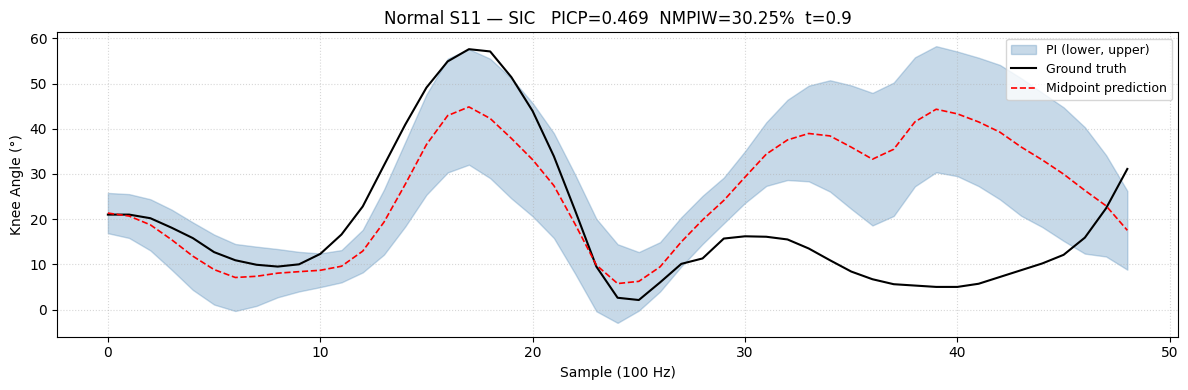

  Saved: pi_Normal_sic_s11.png


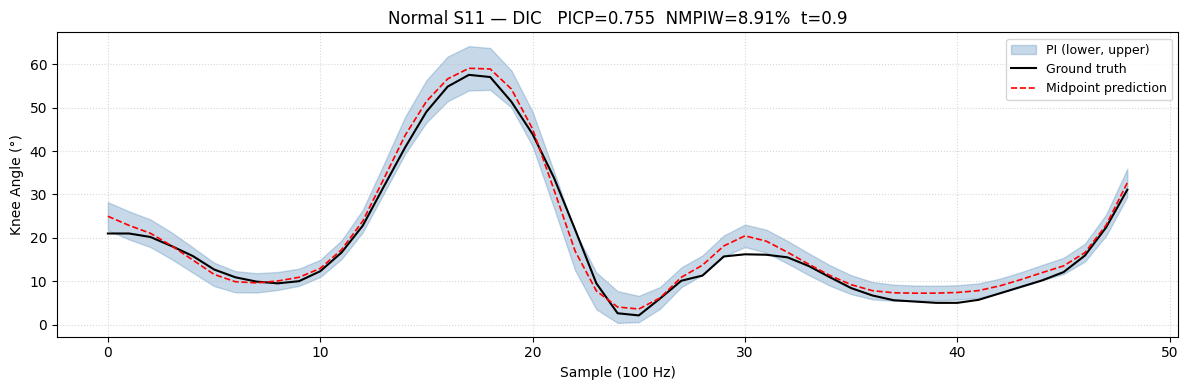

  Saved: pi_Normal_dic_s11.png


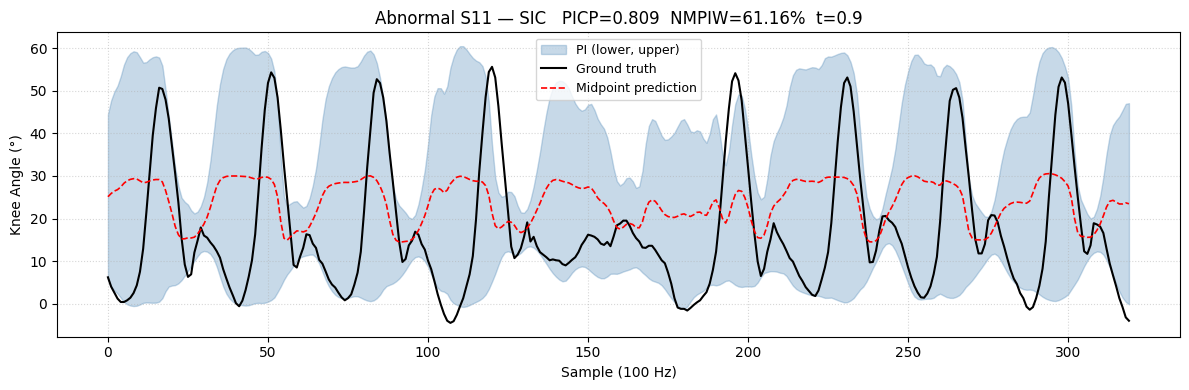

  Saved: pi_Abnormal_sic_s11.png


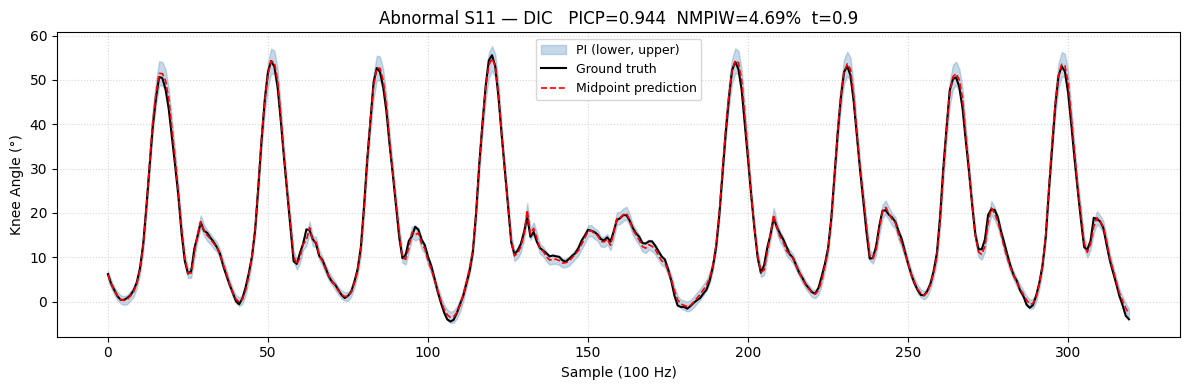

  Saved: pi_Abnormal_dic_s11.png


In [30]:
# ── Cell 22: Visualise prediction intervals (last LOO subject) ────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_pi(trues, mu1, mu2, title, picp, nmpiw, ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(trues))
    ax.fill_between(x, mu1.flatten(), mu2.flatten(), alpha=0.3, color="steelblue", label="PI (lower, upper)")
    ax.plot(x, trues.flatten(),  "k-",  lw=1.5, label="Ground truth")
    ax.plot(x, ((mu1+mu2)/2).flatten(), "r--", lw=1.2, label="Midpoint prediction")
    ax.set_xlabel("Sample (100 Hz)"); ax.set_ylabel("Knee Angle (°)")
    ax.set_title(f"{title}   PICP={picp:.3f}  NMPIW={nmpiw*100:.2f}%  t={cfg.TUBE_T}")
    ax.legend(fontsize=9); ax.grid(True, linestyle=":", alpha=0.5)


# ── Plot the primary (last) LOO subject for each model ────────────────────────
def repredict_and_plot(subject_groups, group_label, loo_idx, model_type="sic"):
    """Re-run inference on the eval half and plot."""
    subj_ids    = sorted(subject_groups.keys(), key=lambda s: int(s))
    test_subj   = subj_ids[loo_idx]
    train_subjs = [s for i, s in enumerate(subj_ids) if i != loo_idx]

    all_knee = []
    for sid in train_subjs:
        res = load_subject_raw_uci(subject_groups[sid])
        if res: _, k = res; all_knee.append(k[:int(len(k)*0.80)])
    if not all_knee: return
    scaler      = KneeScaler().fit(np.concatenate(all_knee))
    train_range = float(np.percentile(np.concatenate(all_knee), 99) -
                        np.percentile(np.concatenate(all_knee), 1))

    res = load_subject_raw_uci(subject_groups[test_subj])
    if res is None: return
    te_emg, te_knee = res

    if model_type == "sic":
        s2_pth = os.path.join(cfg.CHECKPOINT_DIR, f"s2_sic_{group_label.lower()}_loo{loo_idx}.pt")
        if not os.path.isfile(s2_pth): return
        model = load_pretrained_sic_tube()
        model.load_state_dict(torch.load(s2_pth, map_location="cpu", weights_only=False))
        te_X, te_y = create_windows_sic(te_emg, te_knee, scaler)
        half       = max(len(te_X)//2, 1)
        ev_X, ev_y = te_X[half:], te_y[half:]
        full_range = float(scaler.inverse(te_y).max() - scaler.inverse(te_y).min())
        ev_ldr     = make_loader_sic(ev_X, ev_y, 64, False)
        mu1, mu2, trues = predict_bounds_sic(model, ev_ldr, scaler)
    else:
        s2_pth = os.path.join(cfg.CHECKPOINT_DIR, f"s2_dic_{group_label.lower()}_loo{loo_idx}.pt")
        if not os.path.isfile(s2_pth): return
        model = build_dic_from_sic_tube()
        model.load_state_dict(torch.load(s2_pth, map_location="cpu", weights_only=False))
        Xe, Xk, te_y = create_windows_dic(te_emg, te_knee, scaler)
        half         = max(len(Xe)//2, 1)
        ev_Xe, ev_Xk, ev_y = Xe[half:], Xk[half:], te_y[half:]
        full_range   = float(scaler.inverse(te_y).max() - scaler.inverse(te_y).min())
        ev_ldr       = make_loader_dic(ev_Xe, ev_Xk, ev_y, 64, False)
        mu1, mu2, trues = predict_bounds_dic(model, ev_ldr, scaler)

    m = compute_interval_metrics(trues, mu1, mu2, full_range, train_range)
    title = f"{group_label} S{test_subj} — {model_type.upper()}"
    plot_pi(trues, mu1, mu2, title, m["PICP"], m["NMPIW"])
    plt.tight_layout(); plt.savefig(f"pi_{group_label}_{model_type}_s{test_subj}.png", dpi=150)
    plt.show()
    print(f"  Saved: pi_{group_label}_{model_type}_s{test_subj}.png")


# Plot subject 11 for all 4 model/group combos
primary = cfg.PRIMARY_LOO_IDX
for grp_lbl, grp_dir, grp_groups in [
    ("Normal",   cfg.UCI_NORMAL_DIR,   "normal_groups"),
    ("Abnormal", cfg.UCI_ABNORMAL_DIR, "abnormal_groups"),
]:
    if os.path.isdir(grp_dir):
        g = get_subject_groups_uci(grp_dir)
        for mtype in ["sic", "dic"]:
            repredict_and_plot(g, grp_lbl, min(primary, len(g)-1), mtype)

## Section 8 — Re-calibration (Tube Loss δ tuning)
If PICP >> target `t`, increase `δ` to shrink interval width while maintaining coverage.

In [32]:
# ── Cell 23: δ re-calibration scan ────────────────────────────────────────────
# Run this AFTER main LOO evaluation.
# If mean PICP >> cfg.TUBE_T on validation, find the smallest δ that keeps PICP ≥ t.

def recalibrate_delta(model, tr_ldr, vl_ldr, base_delta=0.0, delta_steps=None, run_sic=True):
    """
    Scan δ values; return the one that achieves PICP ≈ target t on the val set
    with minimum NMPIW.
    """
    if delta_steps is None:
        delta_steps = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    best_delta, best_mpiw = base_delta, float("inf")

    for delta in delta_steps:
        crit_tmp = TubeLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=delta)
        # Quick fine-tune with this delta (few epochs)
        opt_tmp  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=5e-5)
        for _ in range(5):
            model.train()
            if run_sic:
                for X, y in tr_ldr:
                    X, y = X.to(cfg.DEVICE), y.to(cfg.DEVICE)
                    pred = model(X)
                    loss = crit_tmp(pred, y)
                    opt_tmp.zero_grad(); loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt_tmp.step()

        # Evaluate PICP on val
        model.eval()
        inside, widths = [], []
        with torch.no_grad():
            if run_sic:
                for X, y in vl_ldr:
                    m1, m2 = model.get_bounds(X.to(cfg.DEVICE))
                    m1, m2 = m1.cpu().numpy().flatten(), m2.cpu().numpy().flatten()
                    yt     = y.numpy().flatten()
                    inside.extend((yt >= m1) & (yt <= m2))
                    widths.extend(m2 - m1)
        picp_val = float(np.mean(inside))
        mpiw_val = float(np.mean(widths))
        print(f"  δ={delta:.4f}  PICP(val)={picp_val:.3f}  MPIW(val)={mpiw_val:.4f}")

        if picp_val >= cfg.TUBE_T and mpiw_val < best_mpiw:
            best_mpiw  = mpiw_val
            best_delta = delta

    print(f"\n  Best δ = {best_delta}  (PICP ≥ {cfg.TUBE_T}, min MPIW)")
    return best_delta

print("Re-calibration function ready.")
print("Usage: best_delta = recalibrate_delta(model, tr_ldr, vl_ldr)")
print("Then retrain with: TubeLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=best_delta)")

Re-calibration function ready.
Usage: best_delta = recalibrate_delta(model, tr_ldr, vl_ldr)
Then retrain with: TubeLoss(t=cfg.TUBE_T, r=cfg.TUBE_R, delta=best_delta)


In [26]:
# ── Cell 24: Quick design guide — changing t and r ────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  TUBE LOSS HYPERPARAMETER GUIDE                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  t   — target confidence level                                   ║
║        t=0.90 → 90% of test samples should fall inside PI        ║
║        t=0.95 → 95% coverage (wider intervals)                   ║
║        For rehabilitation applications: t=0.90 is typical        ║
║                                                                  ║
║  r   — tube position / centering                                 ║
║        r=0.5 → symmetric/centred PI  (default; good for normal   ║
║                gait where knee angle distribution is ~symmetric) ║
║        r<0.5 → shifts tube downward  (use when dist is skewed    ║
║                upward, e.g. stance phase dominates)              ║
║        r>0.5 → shifts tube upward                               ║
║        PRACTICAL TIP: scan r ∈ {0.1,0.2,...,0.9} on val set     ║
║        and pick r with lowest NMPIW while PICP ≥ t              ║
║                                                                  ║
║  δ   — width penalty (re-calibration)                            ║
║        δ=0   → no explicit width penalisation (start here)       ║
║        δ>0   → shrinks intervals; increase if val PICP >> t      ║
║        Scan: {0, 0.001, 0.005, 0.01, 0.05, 0.1}                ║
║                                                                  ║
║  KEY DIFFERENCE from MSE pipeline:                              ║
║   • Model outputs 2 neurons [µ₁, µ₂] instead of 1               ║
║   • Evaluation reports PICP + NMPIW + midpoint NMAE/R²          ║
║   • Paper comparison: use midpoint NMAE (matches Tables 2 & 4)  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║  TUBE LOSS HYPERPARAMETER GUIDE                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  t   — target confidence level                                   ║
║        t=0.90 → 90% of test samples should fall inside PI        ║
║        t=0.95 → 95% coverage (wider intervals)                   ║
║        For rehabilitation applications: t=0.90 is typical        ║
║                                                                  ║
║  r   — tube position / centering                                 ║
║        r=0.5 → symmetric/centred PI  (default; good for normal   ║
║                gait where knee angle distribution is ~symmetric) ║
║        r<0.5 → shifts tube downward  (use when dist is skewed    ║
║                upward, e.g. stance phase dominates)              ║
║        r>0.5 → shifts tube upwa